### **Description**

This recipe shows how to calculate the upper Ocean Heat Content (OHC) using monthly-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
Ocean Heat Content (OHC) is routinely used to characterise the energy stored by the ocean and can be defined using the conservative temperature field at time $t$ as follows:

$$H(\lambda, \phi, t) = c_p \int_{z=-h}^{\eta}  \rho(\lambda, \phi, z, t) \ \Theta (\lambda, \phi, z, t) \ dz$$

where $c_p$ is the specific heat capacity of seawater, $-h$ is the lower depth, $\eta$ is the sea surface, $\rho$ is the in-situ density and $\Theta$ is the conservative temperature.

For a Boussinesq ocean model, such as NEMO, the above equation can be simplified by replacing the in-situ density with the reference density $\rho_o$ and a constant ocean model heat capacity $c_p^o$ in place of $c_p$. 

---

In [1]:
# -- Import required packages -- #
import matplotlib.pyplot as plt
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 NEMO model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [3]:
# Define directory path to ancillary files:
domain_filepath = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_filepath, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the sea water conservative temperature and vertical grid scale factors stored at T-points in a single dataset.**

In [4]:
# Define directory path to model output files:
gridT_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/T1m"

# Construct NEMO model T-grid dataset, including conservative temperature (degC):
# (Combine 75 vertical levels into single chunk for transforming vertical coordinates with dask)
ds_gridT = xr.open_zarr(gridT_url, consolidated=True, chunks={'deptht': 75})

ds_gridT

<xarray.Dataset> Size: 467GB
Dimensions:                (time_counter: 577, y: 331, x: 360, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon                (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 5kB 1976-01-16T12:00...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/74)
    berg_latent_heat_flux  (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    deptht_bounds          (deptht, axis_nbounds) float32 600B dask.array<chunksize=(75, 2), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                     ...
    ttrd_qns_li            (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    vohflisf               (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 21GB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:50 GMT
    uuid:         d4f9020a-a621-4a95-81da-0b477f67ed38

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and T-grid variables for the eORCA1 model.**

In [5]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "gridT": ds_gridT}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 577, axis_nbounds: 2)
│   Coordinates:
│       time_centered         (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│     * time_counter          (time_counter) datetime64[ns] 5kB 1976-01-16T12:00:...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:                (time_counter: 577, j: 331, i: 360, k: 75,
│                                   axis_nbounds: 2)
│       Coordinates:
│         * deptht                 (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered          (time_counter) datetime64[ns] 5kB dask.array<chunksize=(1,), meta=np.ndarray>
│           gphit                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt                  (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                      (j) int64 3kB 1 2 3 4 5 6 ... 326 327 328 329 330 331
│         * i                      (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/80)
│           berg_latent_heat_flux  (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           deptht_bounds          (k, axis_nbounds) float32 600B dask.array<chunksize=(75, 2), meta=np.ndarray>
│           e3t                    (time_counter, k, j, i) float32 21GB dask.array<chunksize=(1, 75, 331, 360), meta=np.ndarray>
│           empmr                  (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           evs                    (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ficeberg               (time_counter, j, i) float32 275MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
│           ...                     ...
│           e1t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t                    (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level              (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level           (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask                  (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil              (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           umaskutil     (j, i) i

### **Calculating Upper Ocean Heat Content**

**Now we have constructed our `NEMODataTree`, let's calculate the Ocean Heat Content of the upper 500 m of the Pacific Ocean.**

$$H_{upper}(t) = \rho_o c_p^o \sum_{z^{*}=0}^{z=500} \sum_{j} \sum_{i} (e_{1t}(j, i) \ . \ e_{2t}(j, i) \ . \ e_{3t}(t, z, j, i) \ . \ \Theta(t, z, j, i))$$

In this example, our eORCA1 model uses $z^{*}$ vertical coordinates with time-evolving vertical grid scale factors, hence $e_{3t}(t, z, j, i)$ is a function of time and space.

Let's start by defining our Pacific Ocean basin mask:


In [6]:
# Define Pacific Ocean basin mask:
pacmask = ds_domain['pacmsk'].rename({"x":"i", "y":"j"}).astype(bool)
# Assign (i,j) coordinates of T-points:
pacmask['i'] = pacmask['i'] + 1
pacmask['j'] = pacmask['j'] + 1

pacmask

<xarray.DataArray 'pacmsk' (j: 331, i: 360)> Size: 119kB
dask.array<astype, shape=(331, 360), dtype=bool, chunksize=(331, 360), chunktype=numpy.ndarray>
Coordinates:
  * i        (i) int64 3kB 1 2 3 4 5 6 7 8 9 ... 353 354 355 356 357 358 359 360
  * j        (j) int64 3kB 1 2 3 4 5 6 7 8 9 ... 324 325 326 327 328 329 330 331

Instead of estimating the upper 500 m ocean heat content by integrating over the `Nk` uppermost vertical levels, such that `deptht[Nk]` is closest to 500 m depth, we can use the `.depth_integral()` method to perform vertical integration between two depth surfaces.

Here, we:

- Select the time period between 2020-2024.
- Apply the Pacific Ocean mask. 
- Integrate first with respect to depth (between 0 - 500 m).
- Integrate over the NEMO model T-grid ($i$, $j$) dimensions.

In [7]:
# Calcuate upper 500m ocean heat content [Zeta Joules = 10^21 Joules] for the entire Pacific Ocean:
rho0 = 1025 # Reference density [kg m-3]
cp0 = 3991.86 # Reference specific heat capacity [J kg-1 C-1]

H_upper = rho0 * cp0 * (nemo["gridT/thetao_con"]
                        .sel(time_counter=slice("2020-01", "2024-01"))
                        .apply_mask(pacmask, drop=True)
                        .depth_integral(limits=(0, 500))
                        .integral(dims=["i", "j"])
                        )

H_upper

/var/folders/z2/j_dr250s42x34hk63_rp4bm80000gq/T/ipykernel_36206/1206376866.py:7: RuntimeWarning: Indexing with a boolean dask array is not allowed. Mask will be computed first using .compute(). This may result in high memory usage for large masks.
  .apply_mask(pacmask, drop=True)


<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ij(integral_z(thetao_con))' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'integral_ij(integral_z(thetao_con))' (time_counter: 49)> Size: 392B
dask.array<mul, shape=(49,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 392B 2020-01-16T12:00:00 ......
    time_centered  (time_counter) datetime64[ns] 392B 2020-01-16T12:00:00 ......

**Notice that the output above contains dask arrays, so we haven't actually computed the Upper Ocean Heat Content yet. To do this, we need to call the ``.compute()`` method:**

In [8]:
H_upper = H_upper.compute()

### **Visualising the evolution of Pacific Upper Ocean Heat Content**

**Finally, let's visualise the results by plotting the time-series of Pacific Upper Ocean Heat Content:**

Text(0, 0.5, 'Upper Ocean Heat Content (ZJ)')

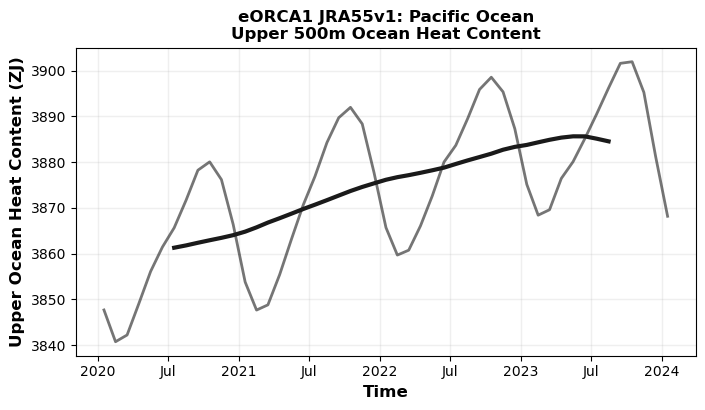

In [10]:
# -- Plotting upper ocean heat content time series for Pacific Ocean -- #
plt.figure(figsize=(8, 4))
plt.grid(True, lw=1, alpha=0.2)

(1E-21 * H_upper).plot(lw=2, color='0.1', alpha=0.6)
(1E-21 * H_upper).rolling(time_counter=12, center=True).mean().plot(lw=3, color='0.1')

# Axes labels:
plt.title('eORCA1 JRA55v1: Pacific Ocean\nUpper 500m Ocean Heat Content', fontdict={'size':12, 'weight':'bold'})
plt.xlabel('Time', fontdict={'size':12, 'weight':'bold'})
plt.ylabel('Upper Ocean Heat Content (ZJ)', fontdict={'size':12, 'weight':'bold'})